<a href="https://colab.research.google.com/github/syedshubha/CrosstalkMTC/blob/main/ReadoutCrosstalk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install --quiet qutip qutip-qip&> /dev/null

In [ ]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

We begin by modeling the spectator qubit ($Q_0$) in the lab frame. It has its own frequency $\omega_{q0}$ and is subjected to a weak crosstalk drive $H_d(t)$ when $c=1$.$$H_{\text{lab}}(t,c) = \frac{\hbar \omega_{q0}}{2} \sigma_z + c \cdot \hbar g \cos(\omega_d t) \sigma_x$$To simplify this, we move into the spectator's rotating frame with the transformation $U_R(t) = \exp(-i\omega_{q0} t \sigma_z / 2)$.

In this new frame, the qubit's own energy term is canceled. After applying the Rotating Wave Approximation (RWA) to drop the fast-oscillating terms at $\omega_{q0} + \omega_d$, we are left with only the terms that oscillate at the detuning frequency, $\Delta = \omega_{q0} - \omega_d$. This gives us our single, unified Hamiltonian in the spectator's rotating frame:$$H_{\text{rot}}(t,c) =
c \cdot \frac{\hbar g}{2}
\left( e^{+ i \Delta t} \sigma_- + e^{- i \Delta t} \sigma_+ \right)$$This Hamiltonian now describes both of our hypotheses:
1.   $H_0$ ($c=0$): $H_{\text{rot}}(0) = 0$. This is our baseline: an idle qubit.
2.   $H_1$ ($c=1$): $H_{\text{rot}}(1)$ is a time-dependent, off-resonant drive.

 We will analyze this in two ways, assuming $g \ll \Delta$.

In [ ]:
# --- Define Physical Constants ---
G_VAL = 2 * np.pi * 5.0     # 5 MHz coupling (g)
DELTA_VAL = 2 * np.pi * 100.0 # 100 MHz detuning (Delta)

# --- Define Qubit Operators ---
psi0 = qt.basis(2, 0)
P0_op = qt.ket2dm(psi0)
P1_op = qt.ket2dm(qt.basis(2, 1))
def Ry(theta):
    return qt.Qobj([[np.cos(theta/2), -np.sin(theta/2)],
                    [np.sin(theta/2),  np.cos(theta/2)]])
Ry_pi_2 = Ry(np.pi / 2) # Ramsey pulse

print(f"Simulating with g = {G_VAL/(2*np.pi)} MHz and Delta = {DELTA_VAL/(2*np.pi)} MHz")

Simulating with g = 5.0 MHz and Delta = 100.0 MHz


In [ ]:
# --- Define the Unified Time-Dependent Hamiltonian ---
def build_hamiltonian(g, delta):

    H_plus_op = 0.5 * g * qt.sigmap()  # sigmap() is |1><0|
    H_minus_op = 0.5 * g * qt.sigmam() # sigmam() is |0><1|

    H_plus_coeff = 'exp(1j * delta * t)'
    H_minus_coeff = 'exp(-1j * delta * t)'

    args = {'delta': delta}

    H = [
        [H_plus_op, H_plus_coeff],
        [H_minus_op, H_minus_coeff]
    ]
    return H, args

In [ ]:
# --- Define the Simulation ---
TAU_MAX = 10.0  # Simulate for 10 microseconds
N_STEPS = 51
tlist = np.linspace(0, TAU_MAX, N_STEPS)
# Build the Hamiltonian
H, args = build_hamiltonian(G_VAL, DELTA_VAL)

# **The Bit-Flip Method**

Circuit: We prepare the spectator in $|0\rangle$, let it evolve under $H_{\text{rot}}(c)$ for the readout duration $\tau$, and then measure $P_1(c) = P(|1\rangle)$.$$S_1 = P_1(c=1) - P_1(c=0) = P_1(c=1) $$
Here $P_1(c=0) = 0$ under $H_0$, $H_{\text{rot}}(0) = 0$, so $U_0(\tau) = I$.

In [ ]:
# --- Run Simulation for S1 (Bit-Flip) ---
s1_options = qt.Options(nsteps=50000)
result_s1 = qt.mesolve(H, psi0, tlist, c_ops=[], e_ops=[P1_op], args=args, options=s1_options)
s1_signal = result_s1.expect[0]

# **Ramsey sequence**
Prepare spectator to $|+\rangle$ by applying $R_Y(\pi/2)$ pulse. Set a target qubit to $|1\rangle$. Run Readout on the target qubit, simultaneously, let the spectator evolve for time $\tau$. Then apply the second $R_Y(\pi/2)$ pulse and record $P(|0\rangle)$.

$S_2 = P_2(c=1) - P_2(c=0) = P_2(c=1) $

Under $H_0$, $U_0(\tau) = I$. The sequence flips $|0\rangle \to |1\rangle$. Therefore, $P(|0\rangle) = 0$.



In [ ]:
# --- Run Simulation for S2 (Ramsey) ---
s2_signal = []
ramsey_options = qt.Options(nsteps=50000)

for i, tau in enumerate(tlist):
    if tau == 0:
        s2_signal.append(0.0)
        continue

    # 1. Prepare |+> state
    psi_1 = Ry_pi_2 * psi0

    # 2. Evolve under the *full* H_rot(1) for time 'tau'
    tlist_step = [0, tau]
    result_step = qt.mesolve(H, psi_1, tlist_step, c_ops=[], e_ops=[], args=args, options=ramsey_options)
    psi_2 = result_step.states[-1]

    # 3. Apply final Ramsey pulse
    psi_3 = Ry_pi_2 * psi_2

    # 4. Measure P(|0>)
    p0 = qt.expect(P0_op, psi_3)
    s2_signal.append(p0)

#Plotting

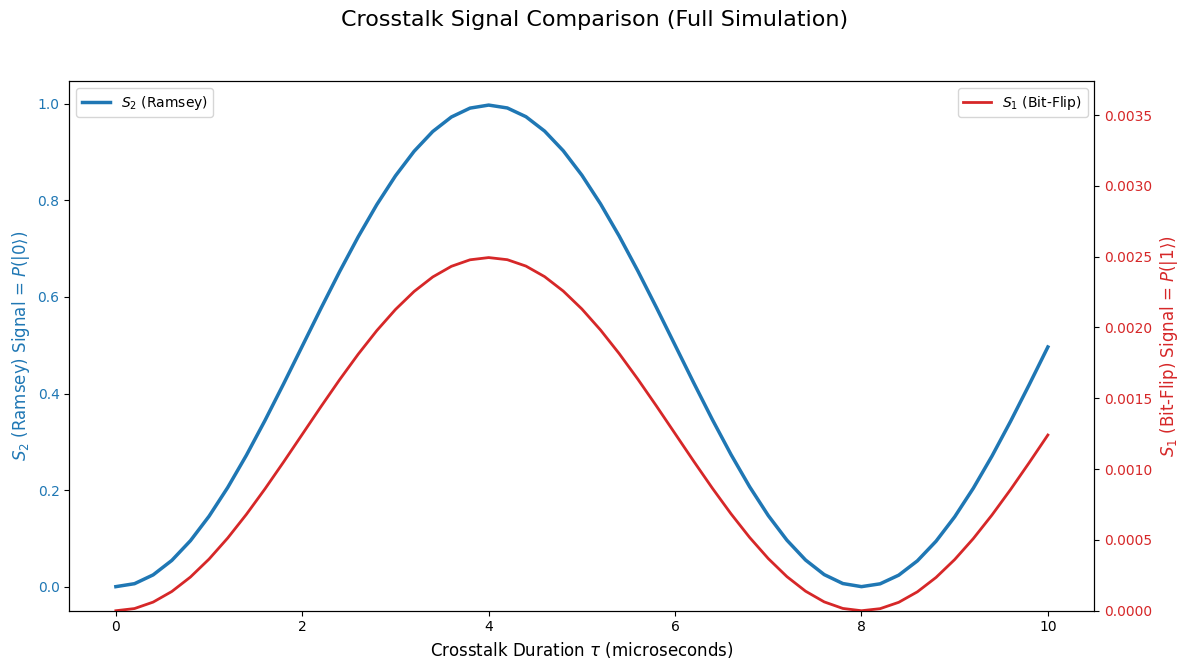

In [ ]:
# --- Matplotlib Plot ---
fig, ax1 = plt.subplots(figsize=(12, 7))
fig.suptitle('Crosstalk Signal Comparison (Full Simulation)', fontsize=16)

color = 'tab:blue'
ax1.set_xlabel('Crosstalk Duration $\\tau$ (microseconds)', fontsize=12)
ax1.set_ylabel('$S_2$ (Ramsey) Signal = $P(|0\\rangle)$', color=color, fontsize=12)
ax1.plot(tlist, s2_signal, color=color, linewidth=2.5, label='$S_2$ (Ramsey)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('$S_1$ (Bit-Flip) Signal = $P(|1\\rangle)$', color=color, fontsize=12)
ax2.plot(tlist, s1_signal, color=color, linewidth=2.0, label='$S_1$ (Bit-Flip)')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

s1_limit = max(s1_signal)*1.5 # 1.5x the max amplitude
ax2.set_ylim(0, s1_limit)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

# Comment
$\Delta_i$ is effectively summation of few $S_1$, which is tiny. However, choosing $\tau$ properly we can have noticeable $S_2$ by pairwise detection.